# 04 — Análises Visuais e Insights

Este notebook explora as tabelas analíticas da camada Gold da Alfabetiza Brasil Data Platform.

Os objetivos são:

- validar os resultados consolidados;
- comparar indicadores e metas;
- identificar desigualdades territoriais;
- localizar municípios prioritários;
- analisar a evolução temporal;
- transformar os dados em insights úteis para tomada de decisão.

In [2]:
from google.colab import auth
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
auth.authenticate_user()

## 1. Conexão com a camada Gold

Nesta etapa, o notebook se conecta ao projeto no Google Cloud e consulta os metadados do dataset Gold.

O objetivo é confirmar que todas as tabelas e views analíticas necessárias estão disponíveis antes do início das análises.

As consultas realizadas neste notebook serão somente de leitura e não modificarão os dados da pipeline.

In [4]:
PROJECT_ID = "macro-coil-475920-k5"
GOLD_DATASET = "gold"
LOCATION = "US"

client = bigquery.Client(
    project=PROJECT_ID,
    location=LOCATION
)

sql_estruturas_gold = f"""
SELECT
  table_name,
  table_type,
  creation_time

FROM
  `{PROJECT_ID}.{GOLD_DATASET}.INFORMATION_SCHEMA.TABLES`

ORDER BY
  table_name
"""

estruturas_gold_df = (
    client
    .query(
        sql_estruturas_gold,
        location=LOCATION
    )
    .result()
    .to_dataframe()
)

display(estruturas_gold_df)

,table_name,table_type,creation_time
0,aluno_analitico,BASE TABLE,2026-07-12 15:59:23.966000+00:00
1,base_ml_aluno,VIEW,2026-07-12 15:59:24.494000+00:00
2,evolucao_municipio,BASE TABLE,2026-07-12 15:59:17.873000+00:00
3,indicador_brasil,BASE TABLE,2026-07-12 15:59:15.621000+00:00
4,indicador_municipio,BASE TABLE,2026-07-12 15:59:12.039000+00:00
5,indicador_uf,BASE TABLE,2026-07-12 15:59:14.030000+00:00
6,resumo_regiao,BASE TABLE,2026-07-12 15:59:19.623000+00:00


## 2. Resumo executivo dos indicadores municipais

A primeira análise consolida os principais resultados municipais de 2024.

Serão calculados:

- quantidade total de registros;
- comparações válidas entre resultado e meta;
- registros que atingiram ou não atingiram a meta;
- percentuais de cumprimento;
- registros sem meta ou resultado disponível;
- médias de resultado, meta e distância até a meta.

Essa visão inicial servirá como referência para validar os números utilizados no README e orientar as análises visuais seguintes.

In [5]:
sql_resumo_2024 = f"""
SELECT
  COUNT(*) AS total_registros_2024,

  COUNTIF(
    resultado_alfabetizacao IS NOT NULL
    AND meta_alfabetizacao_ano IS NOT NULL
  ) AS comparacoes_validas,

  COUNTIF(
    status_meta = 'meta_atingida'
  ) AS registros_meta_atingida,

  COUNTIF(
    status_meta = 'meta_nao_atingida'
  ) AS registros_meta_nao_atingida,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(status_meta = 'meta_atingida'),
      COUNTIF(
        status_meta IN (
          'meta_atingida',
          'meta_nao_atingida'
        )
      )
    ) * 100,
    2
  ) AS percentual_meta_atingida,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(status_meta = 'meta_nao_atingida'),
      COUNTIF(
        status_meta IN (
          'meta_atingida',
          'meta_nao_atingida'
        )
      )
    ) * 100,
    2
  ) AS percentual_meta_nao_atingida,

  COUNTIF(
    meta_alfabetizacao_ano IS NULL
  ) AS registros_sem_meta,

  COUNTIF(
    resultado_alfabetizacao IS NULL
  ) AS registros_sem_resultado,

  ROUND(
    AVG(resultado_alfabetizacao),
    2
  ) AS media_resultado,

  ROUND(
    AVG(meta_alfabetizacao_ano),
    2
  ) AS media_meta,

  ROUND(
    AVG(gap_para_meta),
    2
  ) AS media_gap_para_meta

FROM
  `{PROJECT_ID}.{GOLD_DATASET}.indicador_municipio`

WHERE
  ano = 2024
"""

resumo_2024_df = (
    client
    .query(
        sql_resumo_2024,
        location=LOCATION
    )
    .result()
    .to_dataframe()
)

display(
    resumo_2024_df.T.rename(
        columns={0: "resultado"}
    )
)

,resultado
total_registros_2024,5352
comparacoes_validas,5232
registros_meta_atingida,2788
registros_meta_nao_atingida,2444
percentual_meta_atingida,53.29
percentual_meta_nao_atingida,46.71
registros_sem_meta,120
registros_sem_resultado,0
media_resultado,63.040000000
media_meta,62.150000000


## 3. Cumprimento das metas municipais em 2024

O primeiro gráfico apresenta a distribuição das comparações municipais válidas de 2024 entre:

- registros que atingiram ou superaram a meta;
- registros que não atingiram a meta.

Foram considerados somente registros com resultado e meta disponíveis.

A análise utiliza 5.232 comparações válidas.

,status,quantidade,percentual
0,Meta atingida,2788,53.29
1,Meta não atingida,2444,46.71


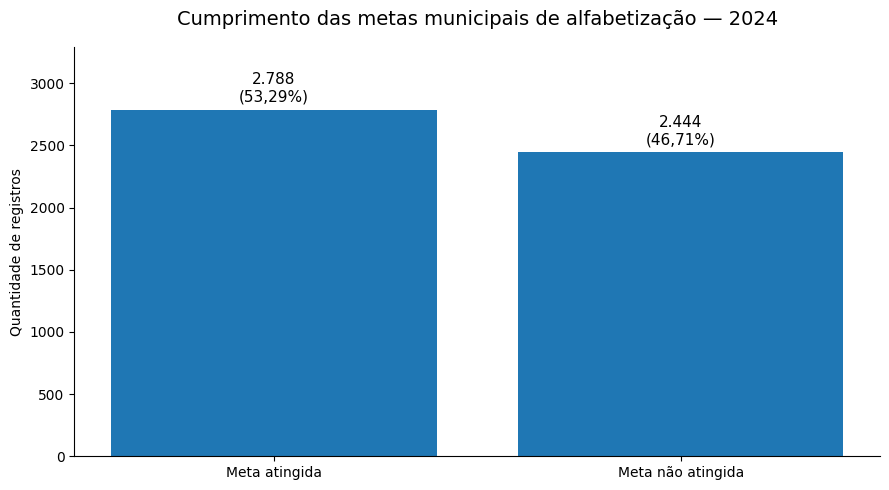

In [6]:
cumprimento_metas_df = pd.DataFrame(
    {
        "status": [
            "Meta atingida",
            "Meta não atingida"
        ],
        "quantidade": [
            int(
                resumo_2024_df.loc[
                    0,
                    "registros_meta_atingida"
                ]
            ),
            int(
                resumo_2024_df.loc[
                    0,
                    "registros_meta_nao_atingida"
                ]
            )
        ],
        "percentual": [
            float(
                resumo_2024_df.loc[
                    0,
                    "percentual_meta_atingida"
                ]
            ),
            float(
                resumo_2024_df.loc[
                    0,
                    "percentual_meta_nao_atingida"
                ]
            )
        ]
    }
)

display(cumprimento_metas_df)

fig, ax = plt.subplots(
    figsize=(9, 5)
)

barras = ax.bar(
    cumprimento_metas_df["status"],
    cumprimento_metas_df["quantidade"]
)

ax.set_title(
    "Cumprimento das metas municipais de alfabetização — 2024",
    fontsize=14,
    pad=16
)

ax.set_ylabel(
    "Quantidade de registros"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for barra, quantidade, percentual in zip(
    barras,
    cumprimento_metas_df["quantidade"],
    cumprimento_metas_df["percentual"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 40,
        f"{quantidade:,}".replace(",", ".")
        + f"\n({percentual:.2f}%)".replace(".", ","),
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_ylim(
    0,
    cumprimento_metas_df["quantidade"].max() * 1.18
)

plt.tight_layout()
plt.show()

## 4. Distância entre o resultado e a meta não atingida

Esta análise considera exclusivamente os registros municipais que não atingiram a meta em 2024.

Serão calculados:

- quantidade de registros abaixo da meta;
- gap médio;
- gap mediano;
- terceiro quartil;
- maior gap observado.

Diferentemente do gap médio geral, esta análise não inclui valores iguais a zero dos registros que atingiram a meta. Portanto, ela representa melhor a intensidade do déficit entre os territórios prioritários.

In [7]:
sql_gap_nao_atingida = f"""
SELECT
  COUNT(*) AS registros_abaixo_meta,

  ROUND(
    AVG(gap_para_meta),
    2
  ) AS gap_medio_pontos_percentuais,

  ROUND(
    APPROX_QUANTILES(
      gap_para_meta,
      100
    )[OFFSET(50)],
    2
  ) AS gap_mediano_pontos_percentuais,

  ROUND(
    APPROX_QUANTILES(
      gap_para_meta,
      100
    )[OFFSET(75)],
    2
  ) AS terceiro_quartil_gap,

  ROUND(
    MAX(gap_para_meta),
    2
  ) AS maior_gap_observado

FROM
  `{PROJECT_ID}.{GOLD_DATASET}.indicador_municipio`

WHERE
  ano = 2024
  AND status_meta = 'meta_nao_atingida'
"""

gap_nao_atingida_df = (
    client
    .query(
        sql_gap_nao_atingida,
        location=LOCATION
    )
    .result()
    .to_dataframe()
)

display(
    gap_nao_atingida_df.T.rename(
        columns={0: "resultado"}
    )
)

,resultado
registros_abaixo_meta,2444
gap_medio_pontos_percentuais,11.280000000
gap_mediano_pontos_percentuais,8.600000000
terceiro_quartil_gap,15.860000000
maior_gap_observado,68.900000000


## 5. Cumprimento das metas por região

Esta análise compara o desempenho das cinco regiões brasileiras em 2024.

Para cada região, serão apresentados:

- quantidade de comparações válidas;
- quantidade de registros que atingiram ou não atingiram a meta;
- percentual de cumprimento;
- resultado médio;
- meta média;
- gap médio entre os registros que não atingiram a meta.

A comparação regional ajuda a identificar desigualdades territoriais que podem ser ocultadas pelos resultados nacionais agregados.

As médias representam médias simples dos registros municipais e não correspondem a indicadores oficiais ponderados pelo número de alunos.

In [8]:
sql_desempenho_regiao = f"""
SELECT
  regiao,

  COUNT(*) AS comparacoes_validas,

  COUNTIF(
    status_meta = 'meta_atingida'
  ) AS registros_meta_atingida,

  COUNTIF(
    status_meta = 'meta_nao_atingida'
  ) AS registros_meta_nao_atingida,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(status_meta = 'meta_atingida'),
      COUNT(*)
    ) * 100,
    2
  ) AS percentual_meta_atingida,

  ROUND(
    AVG(resultado_alfabetizacao),
    2
  ) AS resultado_medio,

  ROUND(
    AVG(meta_alfabetizacao_ano),
    2
  ) AS meta_media,

  ROUND(
    AVG(
      IF(
        status_meta = 'meta_nao_atingida',
        gap_para_meta,
        NULL
      )
    ),
    2
  ) AS gap_medio_entre_nao_atingidos

FROM
  `{PROJECT_ID}.{GOLD_DATASET}.indicador_municipio`

WHERE
  ano = 2024
  AND resultado_alfabetizacao IS NOT NULL
  AND meta_alfabetizacao_ano IS NOT NULL

GROUP BY
  regiao

ORDER BY
  percentual_meta_atingida DESC
"""

desempenho_regiao_df = (
    client
    .query(
        sql_desempenho_regiao,
        location=LOCATION
    )
    .result()
    .to_dataframe()
)

display(desempenho_regiao_df)

,regiao,comparacoes_validas,registros_meta_atingida,registros_meta_nao_atingida,percentual_meta_atingida,resultado_medio,meta_media,gap_medio_entre_nao_atingidos
0,Centro-Oeste,461,337,124,73.10,72.320000000,65.630000000,7.720000000
1,Sudeste,1590,1053,537,66.23,69.980000000,64.230000000,7.830000000
2,Nordeste,1738,871,867,50.12,56.780000000,55.670000000,10.810000000
3,Norte,389,170,219,43.70,50.240000000,50.950000000,9.980000000
4,Sul,1054,357,697,33.87,64.680000000,72.310000000,15.570000000


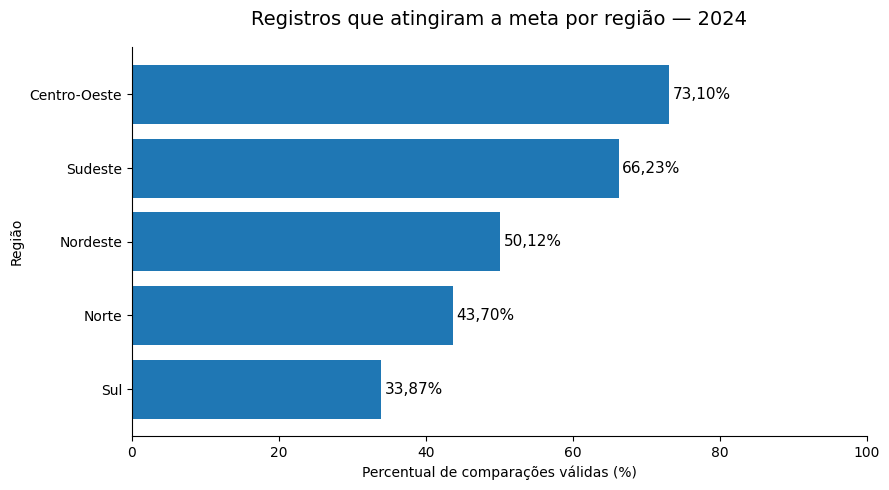

In [9]:
grafico_regiao_df = desempenho_regiao_df.sort_values(
    "percentual_meta_atingida",
    ascending=True
)

fig, ax = plt.subplots(
    figsize=(9, 5)
)

barras = ax.barh(
    grafico_regiao_df["regiao"],
    grafico_regiao_df["percentual_meta_atingida"]
)

ax.set_title(
    "Registros que atingiram a meta por região — 2024",
    fontsize=14,
    pad=16
)

ax.set_xlabel(
    "Percentual de comparações válidas (%)"
)

ax.set_ylabel(
    "Região"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for barra, percentual in zip(
    barras,
    grafico_regiao_df["percentual_meta_atingida"]
):
    ax.text(
        barra.get_width() + 0.5,
        barra.get_y() + barra.get_height() / 2,
        f"{percentual:.2f}%".replace(".", ","),
        va="center",
        fontsize=11
    )

ax.set_xlim(
    0,
    max(
        grafico_regiao_df["percentual_meta_atingida"].max() * 1.15,
        100
    )
)

plt.tight_layout()
plt.show()

## 6. Cumprimento das metas por unidade federativa

A análise regional pode ocultar diferenças relevantes entre as unidades federativas de uma mesma região.

Nesta etapa, serão calculados por UF:

- quantidade de comparações válidas;
- percentual de registros que atingiram a meta;
- resultado médio;
- meta média;
- gap médio entre os registros que não atingiram a meta.

Serão destacados os cinco maiores e os cinco menores percentuais de cumprimento.

Os valores representam médias simples dos registros municipais e não correspondem aos indicadores oficiais ponderados por população ou quantidade de alunos.

In [10]:
sql_desempenho_uf = f"""
SELECT
  sigla_uf,
  regiao,

  COUNT(*) AS comparacoes_validas,

  COUNTIF(
    status_meta = 'meta_atingida'
  ) AS registros_meta_atingida,

  COUNTIF(
    status_meta = 'meta_nao_atingida'
  ) AS registros_meta_nao_atingida,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(status_meta = 'meta_atingida'),
      COUNT(*)
    ) * 100,
    2
  ) AS percentual_meta_atingida,

  ROUND(
    AVG(resultado_alfabetizacao),
    2
  ) AS resultado_medio,

  ROUND(
    AVG(meta_alfabetizacao_ano),
    2
  ) AS meta_media,

  ROUND(
    AVG(
      IF(
        status_meta = 'meta_nao_atingida',
        gap_para_meta,
        NULL
      )
    ),
    2
  ) AS gap_medio_entre_nao_atingidos

FROM
  `{PROJECT_ID}.{GOLD_DATASET}.indicador_municipio`

WHERE
  ano = 2024
  AND resultado_alfabetizacao IS NOT NULL
  AND meta_alfabetizacao_ano IS NOT NULL

GROUP BY
  sigla_uf,
  regiao

ORDER BY
  percentual_meta_atingida DESC
"""

desempenho_uf_df = (
    client
    .query(
        sql_desempenho_uf,
        location=LOCATION
    )
    .result()
    .to_dataframe()
)

display(desempenho_uf_df)

,sigla_uf,regiao,comparacoes_validas,registros_meta_atingida,registros_meta_nao_atingida,percentual_meta_atingida,resultado_medio,meta_media,gap_medio_entre_nao_atingidos
0,CE,Nordeste,184,168,16,91.30,90.310000000,78.930000000,4.930000000
1,GO,Centro-Oeste,243,196,47,80.66,80.190000000,71.870000000,5.150000000
2,MG,Sudeste,801,637,164,79.53,75.070000000,64.760000000,8.450000000
3,ES,Sudeste,78,59,19,75.64,78.190000000,73.540000000,3.960000000
4,MS,Centro-Oeste,79,52,27,65.82,59.030000000,54.710000000,8.680000000
5,MT,Centro-Oeste,139,89,50,64.03,66.110000000,60.920000000,9.620000000
6,PE,Nordeste,184,112,72,60.87,65.580000000,63.230000000,8.030000000
7,PI,Nordeste,224,131,93,58.48,65.990000000,60.060000000,10.860000000
8,TO,Norte,137,77,60,56.20,46.280000000,43.790000000,12.530000000
9,SC,Sul,238,132,106,55.46,69.370000000,68.790000000,9.030000000


## 7. Verificação da cobertura territorial por UF

O ranking anterior apresentou 24 unidades federativas com comparações municipais válidas.

Antes de interpretar o resultado como uma comparação nacional completa, será verificada a cobertura das 27 UFs.

Para cada UF, serão contabilizados:

- registros municipais existentes em 2024;
- registros com resultado disponível;
- registros com meta disponível;
- comparações válidas entre resultado e meta.

Essa verificação permite distinguir ausência territorial de ausência de meta ou resultado.

In [11]:
sql_cobertura_uf = f"""
WITH universo_uf AS (
  SELECT DISTINCT
    sigla_uf,
    regiao

  FROM
    `{PROJECT_ID}.silver.dim_municipio`
),

cobertura AS (
  SELECT
    sigla_uf,

    COUNT(*) AS total_registros_2024,

    COUNTIF(
      resultado_alfabetizacao IS NOT NULL
    ) AS registros_com_resultado,

    COUNTIF(
      meta_alfabetizacao_ano IS NOT NULL
    ) AS registros_com_meta,

    COUNTIF(
      resultado_alfabetizacao IS NOT NULL
      AND meta_alfabetizacao_ano IS NOT NULL
    ) AS comparacoes_validas

  FROM
    `{PROJECT_ID}.{GOLD_DATASET}.indicador_municipio`

  WHERE
    ano = 2024

  GROUP BY
    sigla_uf
)

SELECT
  u.sigla_uf,
  u.regiao,

  COALESCE(
    c.total_registros_2024,
    0
  ) AS total_registros_2024,

  COALESCE(
    c.registros_com_resultado,
    0
  ) AS registros_com_resultado,

  COALESCE(
    c.registros_com_meta,
    0
  ) AS registros_com_meta,

  COALESCE(
    c.comparacoes_validas,
    0
  ) AS comparacoes_validas,

  CASE
    WHEN c.total_registros_2024 IS NULL
      THEN 'sem_registros_em_2024'

    WHEN c.registros_com_resultado = 0
      THEN 'sem_resultado'

    WHEN c.registros_com_meta = 0
      THEN 'sem_meta'

    WHEN c.comparacoes_validas = 0
      THEN 'sem_comparacao_valida'

    WHEN c.comparacoes_validas < c.total_registros_2024
      THEN 'cobertura_parcial'

    ELSE 'cobertura_completa'
  END AS status_cobertura

FROM
  universo_uf AS u

LEFT JOIN
  cobertura AS c
USING
  (sigla_uf)

ORDER BY
  comparacoes_validas,
  sigla_uf
"""

cobertura_uf_df = (
    client
    .query(
        sql_cobertura_uf,
        location=LOCATION
    )
    .result()
    .to_dataframe()
)

display(cobertura_uf_df)

display(
    cobertura_uf_df[
        cobertura_uf_df["comparacoes_validas"] == 0
    ]
)

,sigla_uf,regiao,total_registros_2024,registros_com_resultado,registros_com_meta,comparacoes_validas,status_cobertura
0,AC,Norte,22,22,0,0,sem_meta
1,DF,Centro-Oeste,0,0,0,0,sem_registros_em_2024
2,RR,Norte,0,0,0,0,sem_registros_em_2024
3,AP,Norte,16,16,16,16,cobertura_completa
4,AM,Norte,55,55,48,48,cobertura_parcial
5,RO,Norte,52,52,52,52,cobertura_completa
6,SE,Nordeste,75,75,75,75,cobertura_completa
7,ES,Sudeste,78,78,78,78,cobertura_completa
8,MS,Centro-Oeste,79,79,79,79,cobertura_completa
9,RJ,Sudeste,92,92,90,90,cobertura_parcial


,sigla_uf,regiao,total_registros_2024,registros_com_resultado,registros_com_meta,comparacoes_validas,status_cobertura
0,AC,Norte,22,22,0,0,sem_meta
1,DF,Centro-Oeste,0,0,0,0,sem_registros_em_2024
2,RR,Norte,0,0,0,0,sem_registros_em_2024


## 8. Verificação da granularidade dos registros municipais

Antes de produzir rankings por município, é necessário confirmar a granularidade da tabela `gold.indicador_municipio`.

A análise verificará:

- categorias de rede existentes;
- quantidade de registros por rede;
- quantidade de municípios distintos;
- municípios com mais de um registro em 2024;
- correspondência entre quantidade de registros e municípios.

Essa etapa evita contar o mesmo município mais de uma vez ou interpretar registros por rede como municípios únicos.

In [12]:
sql_granularidade_municipio = f"""
WITH base_2024 AS (
  SELECT
    id_municipio,
    nome_municipio,
    sigla_uf,
    rede

  FROM
    `{PROJECT_ID}.{GOLD_DATASET}.indicador_municipio`

  WHERE
    ano = 2024
),

resumo_rede AS (
  SELECT
    rede,
    COUNT(*) AS total_registros,
    COUNT(DISTINCT id_municipio) AS municipios_distintos

  FROM
    base_2024

  GROUP BY
    rede
),

duplicidade_municipio AS (
  SELECT
    id_municipio,
    COUNT(*) AS quantidade_registros

  FROM
    base_2024

  GROUP BY
    id_municipio
)

SELECT
  rede,
  total_registros,
  municipios_distintos,

  (
    SELECT COUNT(DISTINCT id_municipio)
    FROM base_2024
  ) AS municipios_distintos_total,

  (
    SELECT COUNT(*)
    FROM duplicidade_municipio
    WHERE quantidade_registros > 1
  ) AS municipios_com_multiplos_registros

FROM
  resumo_rede

ORDER BY
  total_registros DESC
"""

granularidade_municipio_df = (
    client
    .query(
        sql_granularidade_municipio,
        location=LOCATION
    )
    .result()
    .to_dataframe()
)

display(granularidade_municipio_df)

,rede,total_registros,municipios_distintos,municipios_distintos_total,municipios_com_multiplos_registros
0,Municipal,5352,5352,5352,0


## 9. Municípios com maior distância até a meta

Esta análise identifica os municípios que apresentaram os maiores déficits em relação à meta de alfabetização em 2024.

Serão considerados somente municípios que:

- possuem resultado e meta disponíveis;
- não atingiram a meta;
- apresentam gap positivo.

O ranking será baseado na diferença, em pontos percentuais, entre a meta estabelecida e o resultado observado.

Essa análise permite localizar territórios prioritários para investigação e acompanhamento, mas não explica, isoladamente, as causas do desempenho.

In [13]:
sql_maiores_gaps_municipios = f"""
SELECT
  id_municipio,
  nome_municipio,
  sigla_uf,
  regiao,
  resultado_alfabetizacao,
  meta_alfabetizacao_ano,
  gap_para_meta,
  percentual_participacao

FROM
  `{PROJECT_ID}.{GOLD_DATASET}.indicador_municipio`

WHERE
  ano = 2024
  AND status_meta = 'meta_nao_atingida'
  AND gap_para_meta IS NOT NULL

ORDER BY
  gap_para_meta DESC

LIMIT
  15
"""

maiores_gaps_municipios_df = (
    client
    .query(
        sql_maiores_gaps_municipios,
        location=LOCATION
    )
    .result()
    .to_dataframe()
)

display(maiores_gaps_municipios_df)

,id_municipio,nome_municipio,sigla_uf,regiao,resultado_alfabetizacao,meta_alfabetizacao_ano,gap_para_meta,percentual_participacao
0,4320453,Sério,RS,Sul,11.100000000,80.000000000,68.900000000,100.000000000
1,4301073,Arroio do Padre,RS,Sul,18.200000000,80.000000000,61.800000000,84.620000000
2,4319752,São Vendelino,RS,Sul,25.000000000,80.000000000,55.000000000,100.000000000
3,4310850,Jaboticaba,RS,Sul,25.000000000,80.000000000,55.000000000,100.000000000
4,4319208,São Nicolau,RS,Sul,7.100000000,61.560000000,54.460000000,82.350000000
5,4306700,Dona Francisca,RS,Sul,26.700000000,80.000000000,53.300000000,93.750000000
6,4302584,Bozano,RS,Sul,27.300000000,80.000000000,52.700000000,100.000000000
7,4313334,Nova Ramada,RS,Sul,28.000000000,80.000000000,52.000000000,96.150000000
8,1713601,Monte do Carmo,TO,Norte,19.710000000,71.560000000,51.850000000,81.010000000
9,4320354,Sentinela do Sul,RS,Sul,23.500000000,74.770000000,51.270000000,85.710000000


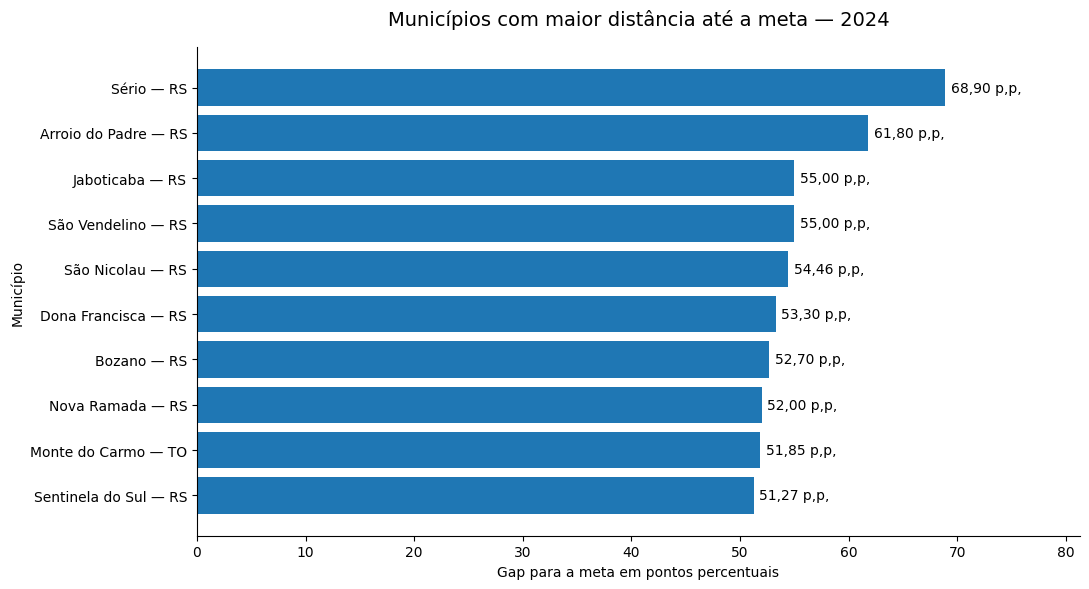

In [15]:
grafico_gaps_df = (
    maiores_gaps_municipios_df
    .head(10)
    .copy()
)

grafico_gaps_df["gap_para_meta"] = (
    grafico_gaps_df["gap_para_meta"]
    .astype(float)
)

grafico_gaps_df = grafico_gaps_df.sort_values(
    "gap_para_meta",
    ascending=True
)

grafico_gaps_df["municipio_uf"] = (
    grafico_gaps_df["nome_municipio"]
    + " — "
    + grafico_gaps_df["sigla_uf"]
)

fig, ax = plt.subplots(
    figsize=(11, 6)
)

barras = ax.barh(
    grafico_gaps_df["municipio_uf"],
    grafico_gaps_df["gap_para_meta"]
)

ax.set_title(
    "Municípios com maior distância até a meta — 2024",
    fontsize=14,
    pad=16
)

ax.set_xlabel(
    "Gap para a meta em pontos percentuais"
)

ax.set_ylabel(
    "Município"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for barra, gap in zip(
    barras,
    grafico_gaps_df["gap_para_meta"]
):
    ax.text(
        barra.get_width() + 0.5,
        barra.get_y() + barra.get_height() / 2,
        f"{gap:.2f} p.p.".replace(".", ","),
        va="center",
        fontsize=10
    )

maior_gap_grafico = float(
    grafico_gaps_df["gap_para_meta"].max()
)

ax.set_xlim(
    0,
    maior_gap_grafico * 1.18
)

plt.tight_layout()
plt.show()

## 10. Evolução municipal entre 2023 e 2024

Esta análise compara os resultados municipais de alfabetização entre 2023 e 2024.

Os municípios serão classificados como:

- `avancou`: aumento de pelo menos 0,01 ponto percentual;
- `recuou`: redução de pelo menos 0,01 ponto percentual;
- `estavel`: variação inferior a 0,01 ponto percentual;
- `sem_base_2023`: ausência de resultado em 2023;
- `sem_resultado_2024`: ausência de resultado em 2024.

Serão calculadas a quantidade e a proporção de municípios em cada situação, além das variações média e mediana entre aqueles que possuem resultados nos dois anos.

In [16]:
sql_resumo_evolucao = f"""
WITH base AS (
  SELECT
    status_evolucao,
    variacao_pontos_percentuais

  FROM
    `{PROJECT_ID}.{GOLD_DATASET}.evolucao_municipio`
)

SELECT
  status_evolucao,
  COUNT(*) AS quantidade_municipios,

  ROUND(
    SAFE_DIVIDE(
      COUNT(*),
      SUM(COUNT(*)) OVER ()
    ) * 100,
    2
  ) AS percentual_municipios,

  ROUND(
    AVG(variacao_pontos_percentuais),
    2
  ) AS variacao_media_pontos_percentuais,

  ROUND(
    APPROX_QUANTILES(
      variacao_pontos_percentuais,
      100
    )[OFFSET(50)],
    2
  ) AS variacao_mediana_pontos_percentuais

FROM
  base

GROUP BY
  status_evolucao

ORDER BY
  quantidade_municipios DESC
"""

resumo_evolucao_df = (
    client
    .query(
        sql_resumo_evolucao,
        location=LOCATION
    )
    .result()
    .to_dataframe()
)

display(resumo_evolucao_df)

,status_evolucao,quantidade_municipios,percentual_municipios,variacao_media_pontos_percentuais,variacao_mediana_pontos_percentuais
0,avancou,3061,57.19,13.030000000,10.130000000
1,recuou,2157,40.30,-11.730000000,-8.090000000
2,sem_base_2023,120,2.24,None,None
3,estavel,14,0.26,0E-9,0E-9


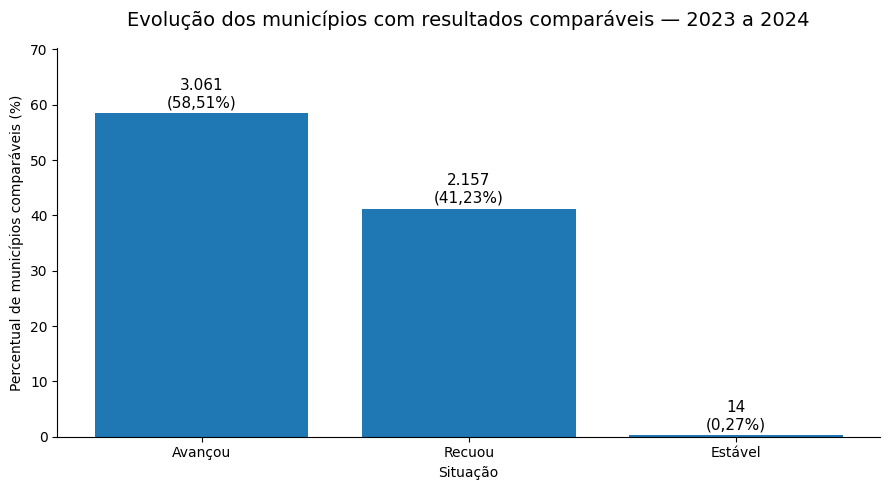

Municípios excluídos por ausência de base em 2023: 120


In [18]:
evolucao_grafico_df = resumo_evolucao_df[
    resumo_evolucao_df["status_evolucao"].isin(
        [
            "avancou",
            "recuou",
            "estavel"
        ]
    )
].copy()

rotulos_evolucao = {
    "avancou": "Avançou",
    "recuou": "Recuou",
    "estavel": "Estável"
}

evolucao_grafico_df["situacao"] = (
    evolucao_grafico_df["status_evolucao"]
    .map(rotulos_evolucao)
)

total_comparavel = (
    evolucao_grafico_df["quantidade_municipios"]
    .sum()
)

evolucao_grafico_df["percentual_comparavel"] = (
    evolucao_grafico_df["quantidade_municipios"]
    .astype(float)
    / float(total_comparavel)
    * 100
)

evolucao_grafico_df = evolucao_grafico_df.sort_values(
    "percentual_comparavel",
    ascending=False
)

fig, ax = plt.subplots(
    figsize=(9, 5)
)

barras = ax.bar(
    evolucao_grafico_df["situacao"],
    evolucao_grafico_df["percentual_comparavel"]
)

ax.set_title(
    "Evolução dos municípios com resultados comparáveis — 2023 a 2024",
    fontsize=14,
    pad=16
)

ax.set_ylabel(
    "Percentual de municípios comparáveis (%)"
)

ax.set_xlabel(
    "Situação"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for barra, percentual, quantidade in zip(
    barras,
    evolucao_grafico_df["percentual_comparavel"],
    evolucao_grafico_df["quantidade_municipios"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.5,
        f"{int(quantidade):,}".replace(",", ".")
        + f"\n({percentual:.2f}%)".replace(".", ","),
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_ylim(
    0,
    evolucao_grafico_df["percentual_comparavel"].max() * 1.20
)

plt.tight_layout()
plt.show()

print(
    "Municípios excluídos por ausência de base em 2023:",
    int(
        resumo_evolucao_df.loc[
            resumo_evolucao_df["status_evolucao"]
            == "sem_base_2023",
            "quantidade_municipios"
        ].iloc[0]
    )
)

## 11. Evolução dos resultados por região

Esta análise compara a evolução municipal entre 2023 e 2024 nas cinco regiões brasileiras.

Para cada região, serão apresentados:

- municípios com resultados comparáveis;
- quantidade que avançou, recuou ou permaneceu estável;
- percentual de municípios que avançaram;
- variação média entre os dois anos.

Os municípios sem resultado disponível em 2023 não serão incluídos no cálculo dos percentuais.

In [19]:
sql_evolucao_regiao = f"""
SELECT
  regiao,

  COUNT(*) AS municipios_comparaveis,

  COUNTIF(
    status_evolucao = 'avancou'
  ) AS municipios_que_avancaram,

  COUNTIF(
    status_evolucao = 'recuou'
  ) AS municipios_que_recuaram,

  COUNTIF(
    status_evolucao = 'estavel'
  ) AS municipios_estaveis,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(status_evolucao = 'avancou'),
      COUNT(*)
    ) * 100,
    2
  ) AS percentual_que_avancou,

  ROUND(
    AVG(variacao_pontos_percentuais),
    2
  ) AS variacao_media_pontos_percentuais

FROM
  `{PROJECT_ID}.{GOLD_DATASET}.evolucao_municipio`

WHERE
  status_evolucao IN (
    'avancou',
    'recuou',
    'estavel'
  )

GROUP BY
  regiao

ORDER BY
  percentual_que_avancou DESC
"""

evolucao_regiao_df = (
    client
    .query(
        sql_evolucao_regiao,
        location=LOCATION
    )
    .result()
    .to_dataframe()
)

display(evolucao_regiao_df)

,regiao,municipios_comparaveis,municipios_que_avancaram,municipios_que_recuaram,municipios_estaveis,percentual_que_avancou,variacao_media_pontos_percentuais
0,Centro-Oeste,461,346,113,2,75.05,7.780000000
1,Sudeste,1590,1147,440,3,72.14,7.820000000
2,Norte,389,238,151,0,61.18,4.100000000
3,Nordeste,1738,1002,728,8,57.65,3.250000000
4,Sul,1054,328,725,1,31.12,-8.240000000


## 12. Evolução temporal e cumprimento da meta

A evolução entre 2023 e 2024 e o cumprimento da meta de 2024 representam dimensões diferentes.

Um município pode:

- avançar e atingir a meta;
- avançar, mas ainda permanecer abaixo da meta;
- recuar, mas continuar acima da meta;
- recuar e também não atingir a meta;
- permanecer estável.

A combinação dessas dimensões permite identificar diferentes níveis de prioridade.

O grupo mais crítico é formado pelos municípios que recuaram e não atingiram a meta de 2024.

Serão considerados somente municípios com:

- resultados comparáveis em 2023 e 2024;
- meta disponível em 2024.

In [20]:
sql_evolucao_meta = f"""
WITH base AS (
  SELECT
    i.id_municipio,
    i.nome_municipio,
    i.sigla_uf,
    i.regiao,
    i.status_meta,
    i.gap_para_meta,
    e.status_evolucao,
    e.variacao_pontos_percentuais,

    CASE
      WHEN
        e.status_evolucao = 'avancou'
        AND i.status_meta = 'meta_atingida'
      THEN 'Avançou e atingiu a meta'

      WHEN
        e.status_evolucao = 'avancou'
        AND i.status_meta = 'meta_nao_atingida'
      THEN 'Avançou, mas não atingiu a meta'

      WHEN
        e.status_evolucao = 'recuou'
        AND i.status_meta = 'meta_atingida'
      THEN 'Recuou, mas atingiu a meta'

      WHEN
        e.status_evolucao = 'recuou'
        AND i.status_meta = 'meta_nao_atingida'
      THEN 'Recuou e não atingiu a meta'

      ELSE 'Estável'
    END AS classificacao

  FROM
    `{PROJECT_ID}.{GOLD_DATASET}.indicador_municipio` AS i

  INNER JOIN
    `{PROJECT_ID}.{GOLD_DATASET}.evolucao_municipio` AS e
  ON
    i.id_municipio = e.id_municipio
    AND i.rede = e.rede

  WHERE
    i.ano = 2024

    AND i.status_meta IN (
      'meta_atingida',
      'meta_nao_atingida'
    )

    AND e.status_evolucao IN (
      'avancou',
      'recuou',
      'estavel'
    )
)

SELECT
  classificacao,

  COUNT(*) AS quantidade_municipios,

  ROUND(
    SAFE_DIVIDE(
      COUNT(*),
      SUM(COUNT(*)) OVER ()
    ) * 100,
    2
  ) AS percentual_municipios,

  ROUND(
    AVG(variacao_pontos_percentuais),
    2
  ) AS variacao_media,

  ROUND(
    AVG(gap_para_meta),
    2
  ) AS gap_medio

FROM
  base

GROUP BY
  classificacao

ORDER BY
  quantidade_municipios DESC
"""

evolucao_meta_df = (
    client
    .query(
        sql_evolucao_meta,
        location=LOCATION
    )
    .result()
    .to_dataframe()
)

display(evolucao_meta_df)

,classificacao,quantidade_municipios,percentual_municipios,variacao_media,gap_medio
0,Avançou e atingiu a meta,2534,48.43,15.180000000,0E-9
1,Recuou e não atingiu a meta,1916,36.62,-12.630000000,13.710000000
2,"Avançou, mas não atingiu a meta",527,10.07,2.680000000,2.450000000
3,"Recuou, mas atingiu a meta",241,4.61,-4.570000000,0E-9
4,Estável,14,0.27,0E-9,0.450000000


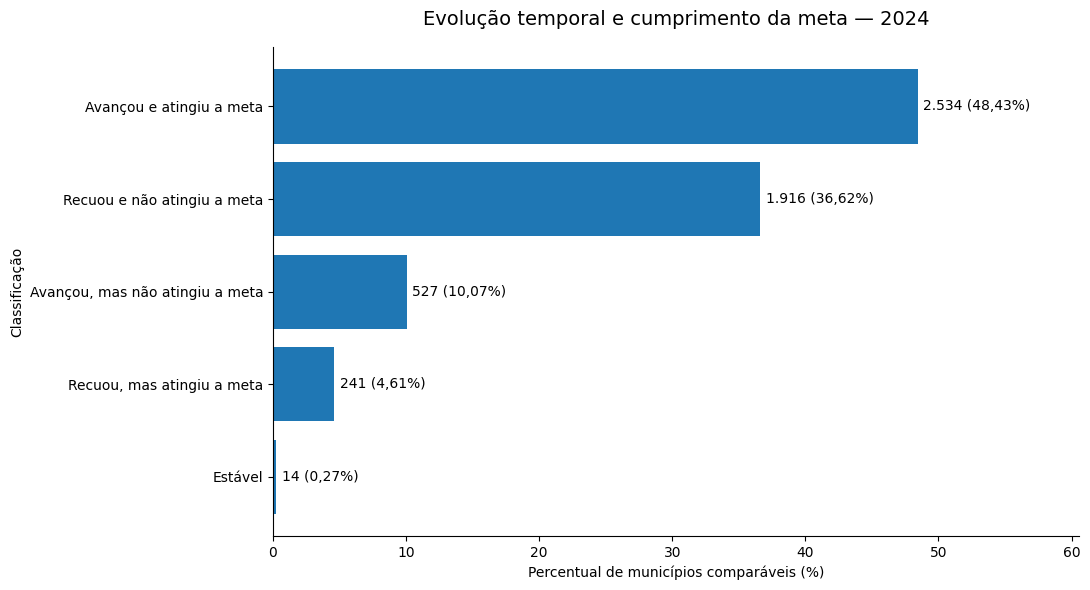

In [21]:
evolucao_meta_grafico_df = (
    evolucao_meta_df
    .copy()
)

evolucao_meta_grafico_df[
    "percentual_municipios"
] = evolucao_meta_grafico_df[
    "percentual_municipios"
].astype(float)

evolucao_meta_grafico_df = (
    evolucao_meta_grafico_df
    .sort_values(
        "percentual_municipios",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(11, 6)
)

barras = ax.barh(
    evolucao_meta_grafico_df["classificacao"],
    evolucao_meta_grafico_df["percentual_municipios"]
)

ax.set_title(
    "Evolução temporal e cumprimento da meta — 2024",
    fontsize=14,
    pad=16
)

ax.set_xlabel(
    "Percentual de municípios comparáveis (%)"
)

ax.set_ylabel(
    "Classificação"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for barra, percentual, quantidade in zip(
    barras,
    evolucao_meta_grafico_df["percentual_municipios"],
    evolucao_meta_grafico_df["quantidade_municipios"]
):
    ax.text(
        barra.get_width() + 0.4,
        barra.get_y() + barra.get_height() / 2,
        f"{int(quantidade):,}".replace(",", ".")
        + f" ({percentual:.2f}%)".replace(".", ","),
        va="center",
        fontsize=10
    )

ax.set_xlim(
    0,
    evolucao_meta_grafico_df[
        "percentual_municipios"
    ].max() * 1.25
)

plt.tight_layout()
plt.show()

## 13. Concentração regional dos municípios críticos

Nesta análise, um município é considerado crítico quando:

- apresentou recuo entre 2023 e 2024;
- não atingiu a meta de alfabetização em 2024.

Para cada região, serão calculados:

- municípios comparáveis com meta disponível;
- quantidade de municípios críticos;
- percentual regional no grupo crítico;
- queda média dos municípios críticos;
- gap médio em relação à meta.

O percentual será calculado dentro de cada região, evitando que regiões com mais municípios sejam consideradas piores apenas por possuírem maior volume de registros.

In [22]:
sql_criticos_regiao = f"""
WITH base AS (
  SELECT
    i.id_municipio,
    i.regiao,
    i.status_meta,
    i.gap_para_meta,
    e.status_evolucao,
    e.variacao_pontos_percentuais

  FROM
    `{PROJECT_ID}.{GOLD_DATASET}.indicador_municipio` AS i

  INNER JOIN
    `{PROJECT_ID}.{GOLD_DATASET}.evolucao_municipio` AS e
  ON
    i.id_municipio = e.id_municipio
    AND i.rede = e.rede

  WHERE
    i.ano = 2024

    AND i.status_meta IN (
      'meta_atingida',
      'meta_nao_atingida'
    )

    AND e.status_evolucao IN (
      'avancou',
      'recuou',
      'estavel'
    )
)

SELECT
  regiao,

  COUNT(*) AS municipios_analisados,

  COUNTIF(
    status_evolucao = 'recuou'
    AND status_meta = 'meta_nao_atingida'
  ) AS municipios_criticos,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(
        status_evolucao = 'recuou'
        AND status_meta = 'meta_nao_atingida'
      ),
      COUNT(*)
    ) * 100,
    2
  ) AS percentual_criticos,

  ROUND(
    AVG(
      IF(
        status_evolucao = 'recuou'
        AND status_meta = 'meta_nao_atingida',
        variacao_pontos_percentuais,
        NULL
      )
    ),
    2
  ) AS variacao_media_criticos,

  ROUND(
    AVG(
      IF(
        status_evolucao = 'recuou'
        AND status_meta = 'meta_nao_atingida',
        gap_para_meta,
        NULL
      )
    ),
    2
  ) AS gap_medio_criticos

FROM
  base

GROUP BY
  regiao

ORDER BY
  percentual_criticos DESC
"""

criticos_regiao_df = (
    client
    .query(
        sql_criticos_regiao,
        location=LOCATION
    )
    .result()
    .to_dataframe()
)

display(criticos_regiao_df)

,regiao,municipios_analisados,municipios_criticos,percentual_criticos,variacao_media_criticos,gap_medio_criticos
0,Sul,1054,656,62.24,-17.210000000,16.450000000
1,Norte,389,151,38.82,-9.440000000,13.140000000
2,Nordeste,1738,621,35.73,-11.020000000,13.960000000
3,Sudeste,1590,394,24.78,-9.350000000,9.960000000
4,Centro-Oeste,461,94,20.39,-10.240000000,9.630000000


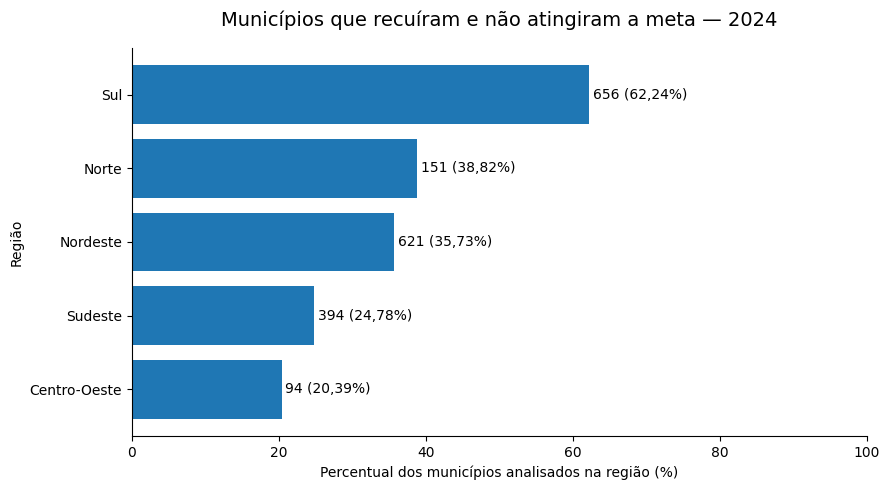

In [23]:
grafico_criticos_regiao_df = (
    criticos_regiao_df
    .sort_values(
        "percentual_criticos",
        ascending=True
    )
    .copy()
)

grafico_criticos_regiao_df["percentual_criticos"] = (
    grafico_criticos_regiao_df[
        "percentual_criticos"
    ].astype(float)
)

fig, ax = plt.subplots(
    figsize=(9, 5)
)

barras = ax.barh(
    grafico_criticos_regiao_df["regiao"],
    grafico_criticos_regiao_df["percentual_criticos"]
)

ax.set_title(
    "Municípios que recuíram e não atingiram a meta — 2024",
    fontsize=14,
    pad=16
)

ax.set_xlabel(
    "Percentual dos municípios analisados na região (%)"
)

ax.set_ylabel(
    "Região"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for barra, percentual, quantidade in zip(
    barras,
    grafico_criticos_regiao_df["percentual_criticos"],
    grafico_criticos_regiao_df["municipios_criticos"]
):
    ax.text(
        barra.get_width() + 0.5,
        barra.get_y() + barra.get_height() / 2,
        f"{int(quantidade):,}".replace(",", ".")
        + f" ({percentual:.2f}%)".replace(".", ","),
        va="center",
        fontsize=10
    )

ax.set_xlim(
    0,
    max(
        grafico_criticos_regiao_df[
            "percentual_criticos"
        ].max() * 1.20,
        100
    )
)

plt.tight_layout()
plt.show()

## 14. Participação na avaliação e resultado de alfabetização

Resultados muito baixos podem ser influenciados por cobertura insuficiente da avaliação.

Esta análise verifica a relação entre:

- percentual de participação;
- resultado de alfabetização;
- cumprimento da meta.

Serão calculados:

- correlação entre participação e resultado;
- distribuição dos municípios por faixa de participação;
- resultado médio em cada faixa;
- percentual de cumprimento da meta em cada faixa.

A correlação será interpretada apenas como associação estatística. Ela não demonstra relação de causa e efeito.

In [26]:
sql_participacao_resumo = f"""
WITH base AS (
  SELECT
    percentual_participacao,
    resultado_alfabetizacao,
    status_meta,

    CASE
      WHEN percentual_participacao < 80
        THEN 'Abaixo de 80%'

      WHEN percentual_participacao < 90
        THEN '80% a 89,99%'

      WHEN percentual_participacao < 95
        THEN '90% a 94,99%'

      ELSE '95% ou mais'
    END AS faixa_participacao

  FROM
    `{PROJECT_ID}.{GOLD_DATASET}.indicador_municipio`

  WHERE
    ano = 2024
    AND percentual_participacao IS NOT NULL
    AND resultado_alfabetizacao IS NOT NULL
)

SELECT
  faixa_participacao,
  COUNT(*) AS quantidade_municipios,

  ROUND(
    AVG(percentual_participacao),
    2
  ) AS participacao_media,

  ROUND(
    AVG(resultado_alfabetizacao),
    2
  ) AS resultado_medio,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(status_meta = 'meta_atingida'),
      COUNTIF(
        status_meta IN (
          'meta_atingida',
          'meta_nao_atingida'
        )
      )
    ) * 100,
    2
  ) AS percentual_meta_atingida,

  ROUND(
    CORR(
      percentual_participacao,
      resultado_alfabetizacao
    ),
    4
  ) AS correlacao_participacao_resultado

FROM
  base

GROUP BY
  faixa_participacao

ORDER BY
  CASE faixa_participacao
    WHEN 'Abaixo de 80%' THEN 1
    WHEN '80% a 89,99%' THEN 2
    WHEN '90% a 94,99%' THEN 3
    ELSE 4
  END
"""

participacao_resumo_df = (
    client
    .query(
        sql_participacao_resumo,
        location=LOCATION
    )
    .result()
    .to_dataframe()
)

display(participacao_resumo_df)

,faixa_participacao,quantidade_municipios,participacao_media,resultado_medio,percentual_meta_atingida,correlacao_participacao_resultado
0,Abaixo de 80%,315,76.020000000,51.870000000,35.89,0.0174
1,"80% a 89,99%",1737,86.110000000,58.780000000,46.35,0.1797
2,"90% a 94,99%",1710,92.520000000,63.350000000,53.47,-0.0405
3,95% ou mais,1590,97.760000000,69.580000000,63.72,0.1917


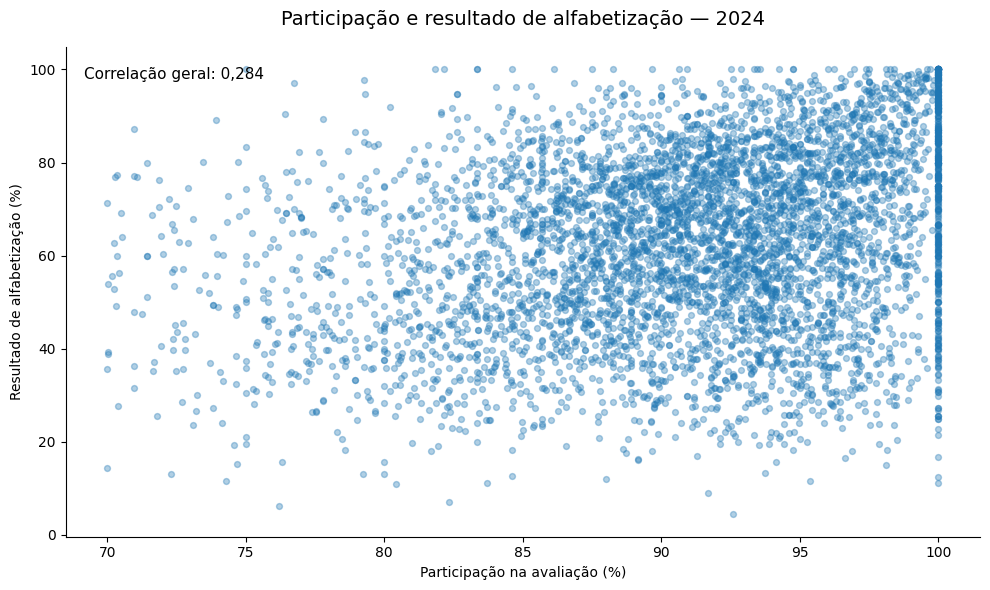

In [25]:
sql_participacao_dispersao = f"""
SELECT
  nome_municipio,
  sigla_uf,
  percentual_participacao,
  resultado_alfabetizacao,
  status_meta

FROM
  `{PROJECT_ID}.{GOLD_DATASET}.indicador_municipio`

WHERE
  ano = 2024
  AND percentual_participacao IS NOT NULL
  AND resultado_alfabetizacao IS NOT NULL
"""

participacao_dispersao_df = (
    client
    .query(
        sql_participacao_dispersao,
        location=LOCATION
    )
    .result()
    .to_dataframe()
)

participacao_dispersao_df["percentual_participacao"] = (
    participacao_dispersao_df[
        "percentual_participacao"
    ].astype(float)
)

participacao_dispersao_df["resultado_alfabetizacao"] = (
    participacao_dispersao_df[
        "resultado_alfabetizacao"
    ].astype(float)
)

correlacao_geral = participacao_dispersao_df[
    [
        "percentual_participacao",
        "resultado_alfabetizacao"
    ]
].corr().iloc[0, 1]

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.scatter(
    participacao_dispersao_df["percentual_participacao"],
    participacao_dispersao_df["resultado_alfabetizacao"],
    alpha=0.35,
    s=18
)

ax.set_title(
    "Participação e resultado de alfabetização — 2024",
    fontsize=14,
    pad=16
)

ax.set_xlabel(
    "Participação na avaliação (%)"
)

ax.set_ylabel(
    "Resultado de alfabetização (%)"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.text(
    0.02,
    0.96,
    f"Correlação geral: {correlacao_geral:.3f}".replace(".", ","),
    transform=ax.transAxes,
    va="top",
    fontsize=11
)

plt.tight_layout()
plt.show()

## 15. Ranking de municípios prioritários

O ranking final considera os municípios que apresentam simultaneamente:

- recuo entre 2023 e 2024;
- meta não atingida em 2024;
- resultado e meta disponíveis.

A ordenação prioriza:

1. maior gap em relação à meta;
2. maior queda entre 2023 e 2024.

O ranking é uma ferramenta de triagem para orientar investigação e acompanhamento. Ele não representa, isoladamente, uma explicação causal do desempenho municipal.

In [27]:
sql_ranking_prioridade = f"""
SELECT
  i.id_municipio,
  i.nome_municipio,
  i.sigla_uf,
  i.regiao,
  i.resultado_alfabetizacao,
  i.meta_alfabetizacao_ano,
  i.gap_para_meta,
  e.resultado_2023,
  e.resultado_2024,
  e.variacao_pontos_percentuais,
  i.percentual_participacao

FROM
  `{PROJECT_ID}.{GOLD_DATASET}.indicador_municipio` AS i

INNER JOIN
  `{PROJECT_ID}.{GOLD_DATASET}.evolucao_municipio` AS e
ON
  i.id_municipio = e.id_municipio
  AND i.rede = e.rede

WHERE
  i.ano = 2024
  AND i.status_meta = 'meta_nao_atingida'
  AND e.status_evolucao = 'recuou'

ORDER BY
  i.gap_para_meta DESC,
  e.variacao_pontos_percentuais ASC

LIMIT
  20
"""

ranking_prioridade_df = (
    client
    .query(
        sql_ranking_prioridade,
        location=LOCATION
    )
    .result()
    .to_dataframe()
)

display(ranking_prioridade_df)

,id_municipio,nome_municipio,sigla_uf,regiao,resultado_alfabetizacao,meta_alfabetizacao_ano,gap_para_meta,resultado_2023,resultado_2024,variacao_pontos_percentuais,percentual_participacao
0,4320453,Sério,RS,Sul,11.100000000,80.000000000,68.900000000,85.400000000,11.100000000,-74.300000000,100.000000000
1,4301073,Arroio do Padre,RS,Sul,18.200000000,80.000000000,61.800000000,94.600000000,18.200000000,-76.400000000,84.620000000
2,4319752,São Vendelino,RS,Sul,25.000000000,80.000000000,55.000000000,100.000000000,25.000000000,-75.000000000,100.000000000
3,4310850,Jaboticaba,RS,Sul,25.000000000,80.000000000,55.000000000,85.500000000,25.000000000,-60.500000000,100.000000000
4,4319208,São Nicolau,RS,Sul,7.100000000,61.560000000,54.460000000,57.900000000,7.100000000,-50.800000000,82.350000000
5,4306700,Dona Francisca,RS,Sul,26.700000000,80.000000000,53.300000000,81.300000000,26.700000000,-54.600000000,93.750000000
6,4302584,Bozano,RS,Sul,27.300000000,80.000000000,52.700000000,100.000000000,27.300000000,-72.700000000,100.000000000
7,4313334,Nova Ramada,RS,Sul,28.000000000,80.000000000,52.000000000,87.000000000,28.000000000,-59.000000000,96.150000000
8,1713601,Monte do Carmo,TO,Norte,19.710000000,71.560000000,51.850000000,70.000000000,19.710000000,-50.290000000,81.010000000
9,4320354,Sentinela do Sul,RS,Sul,23.500000000,74.770000000,51.270000000,73.800000000,23.500000000,-50.300000000,85.710000000


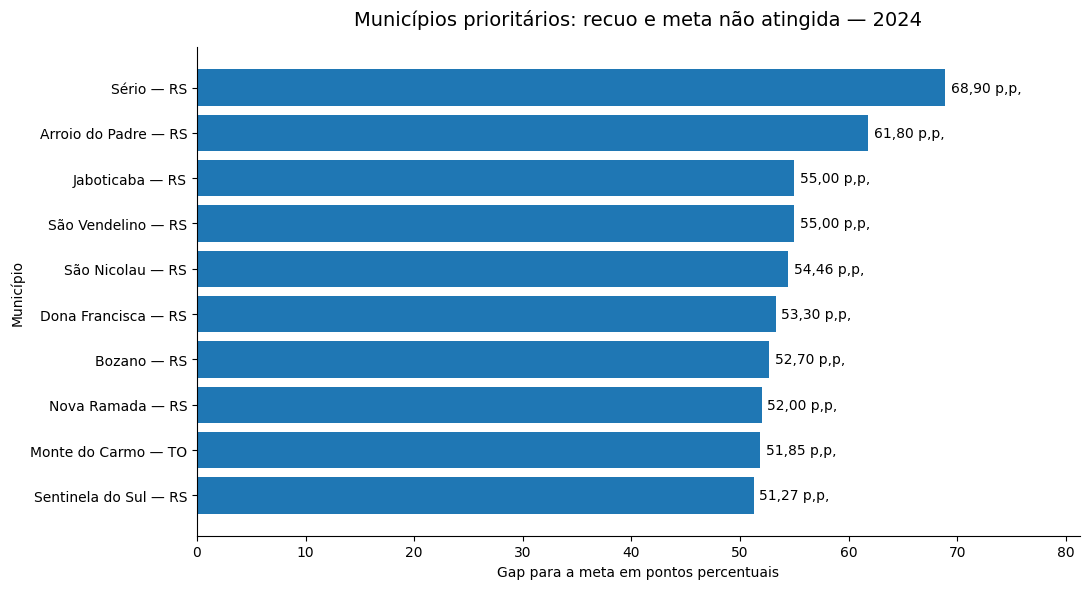

In [28]:
ranking_grafico_df = (
    ranking_prioridade_df
    .head(10)
    .copy()
)

ranking_grafico_df["gap_para_meta"] = (
    ranking_grafico_df["gap_para_meta"]
    .astype(float)
)

ranking_grafico_df = ranking_grafico_df.sort_values(
    "gap_para_meta",
    ascending=True
)

ranking_grafico_df["municipio_uf"] = (
    ranking_grafico_df["nome_municipio"]
    + " — "
    + ranking_grafico_df["sigla_uf"]
)

fig, ax = plt.subplots(
    figsize=(11, 6)
)

barras = ax.barh(
    ranking_grafico_df["municipio_uf"],
    ranking_grafico_df["gap_para_meta"]
)

ax.set_title(
    "Municípios prioritários: recuo e meta não atingida — 2024",
    fontsize=14,
    pad=16
)

ax.set_xlabel(
    "Gap para a meta em pontos percentuais"
)

ax.set_ylabel(
    "Município"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for barra, gap in zip(
    barras,
    ranking_grafico_df["gap_para_meta"]
):
    ax.text(
        barra.get_width() + 0.5,
        barra.get_y() + barra.get_height() / 2,
        f"{gap:.2f} p.p.".replace(".", ","),
        va="center",
        fontsize=10
    )

ax.set_xlim(
    0,
    float(ranking_grafico_df["gap_para_meta"].max()) * 1.18
)

plt.tight_layout()
plt.show()

## 16. Conclusões da análise

A camada Gold permitiu analisar 5.352 municípios com resultado de alfabetização em 2024. Desses, 5.232 também possuíam meta disponível e puderam ser comparados.

### Cumprimento das metas

- 2.788 municípios atingiram ou superaram a meta, correspondendo a 53,29%;
- 2.444 municípios não atingiram a meta, correspondendo a 46,71%;
- 120 municípios não possuíam meta disponível;
- todos os 5.352 municípios possuíam resultado de alfabetização.

Entre os municípios que não atingiram a meta, o gap médio foi de 11,28 pontos percentuais e o gap mediano foi de 8,60 pontos.

### Desigualdade territorial

O Centro-Oeste apresentou o maior percentual de cumprimento das metas, com 73,10%, seguido pelo Sudeste, com 66,23%.

O Sul apresentou o menor percentual, com 33,87%, além do maior gap médio entre os municípios abaixo da meta: 15,57 pontos percentuais.

A análise por UF revelou diferenças expressivas dentro das próprias regiões. Ceará, Goiás e Minas Gerais apresentaram os maiores percentuais de cumprimento, enquanto Rio Grande do Sul, Bahia e Amazonas ficaram entre os menores.

O ranking por UF considerou 24 unidades federativas com ao menos uma comparação municipal válida. O Acre possuía resultados, mas nenhuma meta disponível. Distrito Federal e Roraima não apresentaram registros municipais na base de 2024.

### Evolução entre 2023 e 2024

Entre os 5.232 municípios com resultados comparáveis:

- 3.061 avançaram, correspondendo a 58,51%;
- 2.157 recuaram, correspondendo a 41,23%;
- 14 permaneceram estáveis, correspondendo a 0,27%.

Outros 120 municípios não possuíam base comparável em 2023.

O avanço também foi territorialmente desigual. No Centro-Oeste, 75,05% dos municípios avançaram. No Sul, somente 31,12% avançaram e a variação média regional foi negativa em 8,24 pontos percentuais.

### Evolução e cumprimento da meta

O cruzamento entre evolução e cumprimento revelou:

- 2.534 municípios avançaram e atingiram a meta, correspondendo a 48,43%;
- 1.916 recuaram e não atingiram a meta, correspondendo a 36,62%;
- 527 avançaram, mas ainda ficaram abaixo da meta, correspondendo a 10,07%;
- 241 recuaram, mas permaneceram acima da meta, correspondendo a 4,61%;
- 14 permaneceram estáveis.

O grupo mais crítico, formado pelos municípios que recuíram e não atingiram a meta, apresentou queda média de 12,63 pontos percentuais e gap médio de 13,71 pontos.

No Sul, 62,24% dos municípios analisados pertenciam ao grupo crítico. Esses municípios apresentaram queda média de 17,21 pontos percentuais e gap médio de 16,45 pontos.

### Participação na avaliação

A correlação entre participação e resultado foi positiva, mas fraca, com valor de 0,284.

Mesmo sem indicar causalidade, as faixas de participação apresentaram um gradiente:

- abaixo de 80% de participação: resultado médio de 51,87%;
- entre 80% e 89,99%: resultado médio de 58,78%;
- entre 90% e 94,99%: resultado médio de 63,35%;
- 95% ou mais: resultado médio de 69,58%.

Os resultados sugerem associação entre maior participação e melhor desempenho, mas outras características municipais podem influenciar simultaneamente as duas variáveis.

### Municípios prioritários

O ranking final combinou recuo temporal e descumprimento da meta.

Os maiores gaps foram encontrados em Sério–RS, Arroio do Padre–RS, São Vendelino–RS, Jaboticaba–RS e São Nicolau–RS.

Nove dos dez primeiros municípios do ranking pertencem ao Rio Grande do Sul. As variações extremas devem orientar investigações adicionais sobre composição das turmas, quantidade de alunos, contexto territorial e metodologia da avaliação.

O ranking representa uma ferramenta de priorização e não uma explicação causal do desempenho educacional.

## 17. Exportação das análises

As tabelas e os principais gráficos serão exportados para o Google Drive.

Os arquivos poderão ser utilizados:

- no repositório GitHub;
- no README principal;
- na apresentação executiva;
- no vídeo do projeto;
- como evidência dos resultados obtidos a partir da camada Gold.

In [30]:
from google.colab import drive
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

variaveis_obrigatorias = [
    "resumo_2024_df",
    "gap_nao_atingida_df",
    "desempenho_regiao_df",
    "desempenho_uf_df",
    "cobertura_uf_df",
    "granularidade_municipio_df",
    "maiores_gaps_municipios_df",
    "resumo_evolucao_df",
    "evolucao_regiao_df",
    "evolucao_meta_df",
    "criticos_regiao_df",
    "participacao_resumo_df",
    "participacao_dispersao_df",
    "ranking_prioridade_df"
]

variaveis_ausentes = [
    nome
    for nome in variaveis_obrigatorias
    if nome not in globals()
]

if variaveis_ausentes:
    raise RuntimeError(
        "Execute as células anteriores antes da exportação. "
        f"Variáveis ausentes: {variaveis_ausentes}"
    )

drive.mount(
    "/content/drive",
    force_remount=False
)

output_dir = Path(
    "/content/drive/MyDrive/"
    "tech_challenge_alfabetizacao/"
    "analises_visuais"
)

graficos_dir = output_dir / "graficos"
tabelas_dir = output_dir / "tabelas"

graficos_dir.mkdir(
    parents=True,
    exist_ok=True
)

tabelas_dir.mkdir(
    parents=True,
    exist_ok=True
)

tabelas = {
    "01_resumo_2024.csv": resumo_2024_df,
    "02_gap_meta_nao_atingida.csv": gap_nao_atingida_df,
    "03_desempenho_regiao.csv": desempenho_regiao_df,
    "04_desempenho_uf.csv": desempenho_uf_df,
    "05_cobertura_uf.csv": cobertura_uf_df,
    "06_granularidade_municipio.csv": granularidade_municipio_df,
    "07_maiores_gaps_municipios.csv": maiores_gaps_municipios_df,
    "08_resumo_evolucao.csv": resumo_evolucao_df,
    "09_evolucao_regiao.csv": evolucao_regiao_df,
    "10_evolucao_meta.csv": evolucao_meta_df,
    "11_criticos_regiao.csv": criticos_regiao_df,
    "12_participacao_resumo.csv": participacao_resumo_df,
    "13_ranking_prioridade.csv": ranking_prioridade_df
}

for nome_arquivo, dataframe in tabelas.items():
    dataframe.to_csv(
        tabelas_dir / nome_arquivo,
        index=False
    )

cumprimento_export_df = pd.DataFrame(
    {
        "status": [
            "Meta atingida",
            "Meta não atingida"
        ],
        "quantidade": [
            int(
                resumo_2024_df.loc[
                    0,
                    "registros_meta_atingida"
                ]
            ),
            int(
                resumo_2024_df.loc[
                    0,
                    "registros_meta_nao_atingida"
                ]
            )
        ],
        "percentual": [
            float(
                resumo_2024_df.loc[
                    0,
                    "percentual_meta_atingida"
                ]
            ),
            float(
                resumo_2024_df.loc[
                    0,
                    "percentual_meta_nao_atingida"
                ]
            )
        ]
    }
)

fig, ax = plt.subplots(
    figsize=(9, 5)
)

barras = ax.bar(
    cumprimento_export_df["status"],
    cumprimento_export_df["quantidade"]
)

ax.set_title(
    "Cumprimento das metas municipais de alfabetização — 2024",
    fontsize=14,
    pad=16
)

ax.set_ylabel(
    "Quantidade de municípios"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for barra, quantidade, percentual in zip(
    barras,
    cumprimento_export_df["quantidade"],
    cumprimento_export_df["percentual"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 40,
        f"{int(quantidade):,}".replace(",", ".")
        + f"\n({float(percentual):.2f}%)".replace(".", ","),
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_ylim(
    0,
    float(
        cumprimento_export_df[
            "quantidade"
        ].max()
    ) * 1.18
)

plt.tight_layout()

fig.savefig(
    graficos_dir / "01_cumprimento_metas.png",
    dpi=200,
    bbox_inches="tight"
)

plt.close(fig)

regiao_export_df = desempenho_regiao_df.copy()

regiao_export_df["percentual_meta_atingida"] = pd.to_numeric(
    regiao_export_df["percentual_meta_atingida"],
    errors="coerce"
)

regiao_export_df = regiao_export_df.sort_values(
    "percentual_meta_atingida",
    ascending=True
)

fig, ax = plt.subplots(
    figsize=(9, 5)
)

barras = ax.barh(
    regiao_export_df["regiao"],
    regiao_export_df["percentual_meta_atingida"]
)

ax.set_title(
    "Municípios que atingiram a meta por região — 2024",
    fontsize=14,
    pad=16
)

ax.set_xlabel(
    "Percentual de comparações válidas (%)"
)

ax.set_ylabel(
    "Região"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for barra, percentual in zip(
    barras,
    regiao_export_df["percentual_meta_atingida"]
):
    ax.text(
        barra.get_width() + 0.5,
        barra.get_y() + barra.get_height() / 2,
        f"{float(percentual):.2f}%".replace(".", ","),
        va="center",
        fontsize=11
    )

ax.set_xlim(
    0,
    100
)

plt.tight_layout()

fig.savefig(
    graficos_dir / "02_cumprimento_regiao.png",
    dpi=200,
    bbox_inches="tight"
)

plt.close(fig)

uf_base_export_df = desempenho_uf_df.copy()

uf_base_export_df["percentual_meta_atingida"] = pd.to_numeric(
    uf_base_export_df["percentual_meta_atingida"],
    errors="coerce"
)

melhores_uf_export_df = (
    uf_base_export_df
    .nlargest(
        5,
        "percentual_meta_atingida"
    )
    .copy()
)

piores_uf_export_df = (
    uf_base_export_df
    .nsmallest(
        5,
        "percentual_meta_atingida"
    )
    .sort_values(
        "percentual_meta_atingida",
        ascending=True
    )
    .copy()
)

uf_export_df = pd.concat(
    [
        piores_uf_export_df,
        melhores_uf_export_df.sort_values(
            "percentual_meta_atingida",
            ascending=True
        )
    ],
    ignore_index=True
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

barras = ax.barh(
    uf_export_df["sigla_uf"],
    uf_export_df["percentual_meta_atingida"]
)

ax.set_title(
    "Maiores e menores percentuais de cumprimento por UF — 2024",
    fontsize=14,
    pad=16
)

ax.set_xlabel(
    "Percentual de comparações válidas (%)"
)

ax.set_ylabel(
    "Unidade federativa"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for barra, percentual in zip(
    barras,
    uf_export_df["percentual_meta_atingida"]
):
    ax.text(
        barra.get_width() + 0.7,
        barra.get_y() + barra.get_height() / 2,
        f"{float(percentual):.2f}%".replace(".", ","),
        va="center",
        fontsize=10
    )

ax.set_xlim(
    0,
    100
)

plt.tight_layout()

fig.savefig(
    graficos_dir / "03_destaques_uf.png",
    dpi=200,
    bbox_inches="tight"
)

plt.close(fig)

evolucao_export_df = resumo_evolucao_df[
    resumo_evolucao_df["status_evolucao"].isin(
        [
            "avancou",
            "recuou",
            "estavel"
        ]
    )
].copy()

rotulos_evolucao = {
    "avancou": "Avançou",
    "recuou": "Recuou",
    "estavel": "Estável"
}

evolucao_export_df["situacao"] = (
    evolucao_export_df["status_evolucao"]
    .map(rotulos_evolucao)
)

evolucao_export_df["quantidade_municipios"] = pd.to_numeric(
    evolucao_export_df["quantidade_municipios"],
    errors="coerce"
)

total_comparavel = float(
    evolucao_export_df[
        "quantidade_municipios"
    ].sum()
)

evolucao_export_df["percentual_comparavel"] = (
    evolucao_export_df[
        "quantidade_municipios"
    ]
    / total_comparavel
    * 100
)

evolucao_export_df = evolucao_export_df.sort_values(
    "percentual_comparavel",
    ascending=False
)

fig, ax = plt.subplots(
    figsize=(9, 5)
)

barras = ax.bar(
    evolucao_export_df["situacao"],
    evolucao_export_df["percentual_comparavel"]
)

ax.set_title(
    "Evolução dos municípios com resultados comparáveis — 2023 a 2024",
    fontsize=14,
    pad=16
)

ax.set_ylabel(
    "Percentual de municípios comparáveis (%)"
)

ax.set_xlabel(
    "Situação"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for barra, percentual, quantidade in zip(
    barras,
    evolucao_export_df["percentual_comparavel"],
    evolucao_export_df["quantidade_municipios"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.5,
        f"{int(quantidade):,}".replace(",", ".")
        + f"\n({float(percentual):.2f}%)".replace(".", ","),
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_ylim(
    0,
    float(
        evolucao_export_df[
            "percentual_comparavel"
        ].max()
    ) * 1.20
)

plt.tight_layout()

fig.savefig(
    graficos_dir / "04_evolucao_municipios.png",
    dpi=200,
    bbox_inches="tight"
)

plt.close(fig)

evolucao_meta_export_df = evolucao_meta_df.copy()

evolucao_meta_export_df["percentual_municipios"] = pd.to_numeric(
    evolucao_meta_export_df["percentual_municipios"],
    errors="coerce"
)

evolucao_meta_export_df = evolucao_meta_export_df.sort_values(
    "percentual_municipios",
    ascending=True
)

fig, ax = plt.subplots(
    figsize=(11, 6)
)

barras = ax.barh(
    evolucao_meta_export_df["classificacao"],
    evolucao_meta_export_df["percentual_municipios"]
)

ax.set_title(
    "Evolução temporal e cumprimento da meta — 2024",
    fontsize=14,
    pad=16
)

ax.set_xlabel(
    "Percentual de municípios comparáveis (%)"
)

ax.set_ylabel(
    "Classificação"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for barra, percentual, quantidade in zip(
    barras,
    evolucao_meta_export_df["percentual_municipios"],
    evolucao_meta_export_df["quantidade_municipios"]
):
    ax.text(
        barra.get_width() + 0.4,
        barra.get_y() + barra.get_height() / 2,
        f"{int(quantidade):,}".replace(",", ".")
        + f" ({float(percentual):.2f}%)".replace(".", ","),
        va="center",
        fontsize=10
    )

ax.set_xlim(
    0,
    float(
        evolucao_meta_export_df[
            "percentual_municipios"
        ].max()
    ) * 1.25
)

plt.tight_layout()

fig.savefig(
    graficos_dir / "05_evolucao_e_meta.png",
    dpi=200,
    bbox_inches="tight"
)

plt.close(fig)

criticos_export_df = criticos_regiao_df.copy()

criticos_export_df["percentual_criticos"] = pd.to_numeric(
    criticos_export_df["percentual_criticos"],
    errors="coerce"
)

criticos_export_df = criticos_export_df.sort_values(
    "percentual_criticos",
    ascending=True
)

fig, ax = plt.subplots(
    figsize=(9, 5)
)

barras = ax.barh(
    criticos_export_df["regiao"],
    criticos_export_df["percentual_criticos"]
)

ax.set_title(
    "Municípios que recuíram e não atingiram a meta — 2024",
    fontsize=14,
    pad=16
)

ax.set_xlabel(
    "Percentual dos municípios analisados na região (%)"
)

ax.set_ylabel(
    "Região"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for barra, percentual, quantidade in zip(
    barras,
    criticos_export_df["percentual_criticos"],
    criticos_export_df["municipios_criticos"]
):
    ax.text(
        barra.get_width() + 0.5,
        barra.get_y() + barra.get_height() / 2,
        f"{int(quantidade):,}".replace(",", ".")
        + f" ({float(percentual):.2f}%)".replace(".", ","),
        va="center",
        fontsize=10
    )

ax.set_xlim(
    0,
    100
)

plt.tight_layout()

fig.savefig(
    graficos_dir / "06_criticos_regiao.png",
    dpi=200,
    bbox_inches="tight"
)

plt.close(fig)

participacao_export_df = participacao_dispersao_df.copy()

participacao_export_df["percentual_participacao"] = pd.to_numeric(
    participacao_export_df["percentual_participacao"],
    errors="coerce"
)

participacao_export_df["resultado_alfabetizacao"] = pd.to_numeric(
    participacao_export_df["resultado_alfabetizacao"],
    errors="coerce"
)

participacao_export_df = participacao_export_df.dropna(
    subset=[
        "percentual_participacao",
        "resultado_alfabetizacao"
    ]
)

correlacao_geral_exportacao = (
    participacao_export_df[
        [
            "percentual_participacao",
            "resultado_alfabetizacao"
        ]
    ]
    .corr()
    .iloc[0, 1]
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.scatter(
    participacao_export_df["percentual_participacao"],
    participacao_export_df["resultado_alfabetizacao"],
    alpha=0.35,
    s=18
)

ax.set_title(
    "Participação e resultado de alfabetização — 2024",
    fontsize=14,
    pad=16
)

ax.set_xlabel(
    "Participação na avaliação (%)"
)

ax.set_ylabel(
    "Resultado de alfabetização (%)"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.text(
    0.02,
    0.96,
    f"Correlação geral: {correlacao_geral_exportacao:.3f}".replace(".", ","),
    transform=ax.transAxes,
    va="top",
    fontsize=11
)

plt.tight_layout()

fig.savefig(
    graficos_dir / "07_participacao_resultado.png",
    dpi=200,
    bbox_inches="tight"
)

plt.close(fig)

ranking_export_df = (
    ranking_prioridade_df
    .head(10)
    .copy()
)

ranking_export_df["gap_para_meta"] = pd.to_numeric(
    ranking_export_df["gap_para_meta"],
    errors="coerce"
)

ranking_export_df["municipio_uf"] = (
    ranking_export_df["nome_municipio"]
    + " — "
    + ranking_export_df["sigla_uf"]
)

ranking_export_df = ranking_export_df.sort_values(
    "gap_para_meta",
    ascending=True
)

fig, ax = plt.subplots(
    figsize=(11, 6)
)

barras = ax.barh(
    ranking_export_df["municipio_uf"],
    ranking_export_df["gap_para_meta"]
)

ax.set_title(
    "Municípios prioritários: recuo e meta não atingida — 2024",
    fontsize=14,
    pad=16
)

ax.set_xlabel(
    "Gap para a meta em pontos percentuais"
)

ax.set_ylabel(
    "Município"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for barra, gap in zip(
    barras,
    ranking_export_df["gap_para_meta"]
):
    ax.text(
        barra.get_width() + 0.5,
        barra.get_y() + barra.get_height() / 2,
        f"{float(gap):.2f} p.p.".replace(".", ","),
        va="center",
        fontsize=10
    )

ax.set_xlim(
    0,
    float(
        ranking_export_df[
            "gap_para_meta"
        ].max()
    ) * 1.18
)

plt.tight_layout()

fig.savefig(
    graficos_dir / "08_ranking_prioridade.png",
    dpi=200,
    bbox_inches="tight"
)

plt.close(fig)

manifesto_analises = {
    "municipios_2024": 5352,
    "comparacoes_validas": 5232,
    "meta_atingida": 2788,
    "percentual_meta_atingida": 53.29,
    "meta_nao_atingida": 2444,
    "percentual_meta_nao_atingida": 46.71,
    "municipios_sem_meta": 120,
    "municipios_sem_resultado": 0,
    "gap_medio_entre_nao_atingidos": 11.28,
    "gap_mediano_entre_nao_atingidos": 8.60,
    "municipios_que_avancaram": 3061,
    "percentual_que_avancou": 58.51,
    "municipios_que_recuaram": 2157,
    "percentual_que_recuou": 41.23,
    "municipios_estaveis": 14,
    "municipios_criticos": 1916,
    "percentual_municipios_criticos": 36.62,
    "correlacao_participacao_resultado": round(
        float(correlacao_geral_exportacao),
        4
    ),
    "tabelas_exportadas": len(tabelas),
    "graficos_exportados": 8
}

with open(
    output_dir / "manifesto_analises.json",
    "w",
    encoding="utf-8"
) as arquivo:
    json.dump(
        manifesto_analises,
        arquivo,
        ensure_ascii=False,
        indent=2
    )

print("=" * 70)
print("ANÁLISES VISUAIS EXPORTADAS")
print("=" * 70)
print(f"Diretório: {output_dir}")
print(f"Tabelas exportadas: {len(tabelas)}")
print("Gráficos exportados: 8")
print("Manifesto: manifesto_analises.json")
print("Notebook de análises concluído.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ANÁLISES VISUAIS EXPORTADAS
Diretório: /content/drive/MyDrive/tech_challenge_alfabetizacao/analises_visuais
Tabelas exportadas: 13
Gráficos exportados: 8
Manifesto: manifesto_analises.json
Notebook de análises concluído.
